In [1]:
from utils_ml import *
from tqdm import tqdm 

In [2]:
# Load and concatenate all features
file_prefix = "dataExt/P"
file_suffix = "_intensity.pkl"
num_files = 35

label_arr = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()
features_memmap = np.load('dataExt/features_selected.npy', mmap_mode='r+')

### tune hyperparameters

In [3]:
X_train, X_test, y_train, y_test = train_test_split(features_memmap, label_arr, test_size=0.1, random_state=42)

In [4]:
kfold = KFold(n_splits=2, shuffle=True, random_state=42)
kfold_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
   
    clf = CatBoostClassifier(
        verbose=100,           
        random_state=fold,
        iterations=100
        )
    
    clf.fit(X_train[train_idx], y_train[train_idx], eval_set=(X_train[val_idx],y_train[val_idx]), plot=True)
    kfold_models.append(clf)
    clf.save_model(f"saved_models/model_fold_clf_35_{fold}")
    break 

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.287921
0:	learn: 2.2724052	test: 2.2722499	best: 2.2722499 (0)	total: 5.02s	remaining: 8m 16s
99:	learn: 0.8409492	test: 0.8945833	best: 0.8945833 (99)	total: 8m 59s	remaining: 0us

bestTest = 0.8945832568
bestIteration = 99



In [10]:
acc_arr = []
for cnt, submodel in enumerate(kfold_models):
    
    _pred = submodel.predict(X_test)
    acc_arr.extend([np.sum(_pred.flatten()==y_test)/np.sum(np.ones_like(y_test))]) 

print(f"Test Accuracy = {np.mean(acc_arr):.4f} +/- {np.std(acc_arr):.3f}")

Test Accuracy = 0.6479 +/- 0.000


100%|██████████| 35/35 [01:20<00:00,  2.31s/it]


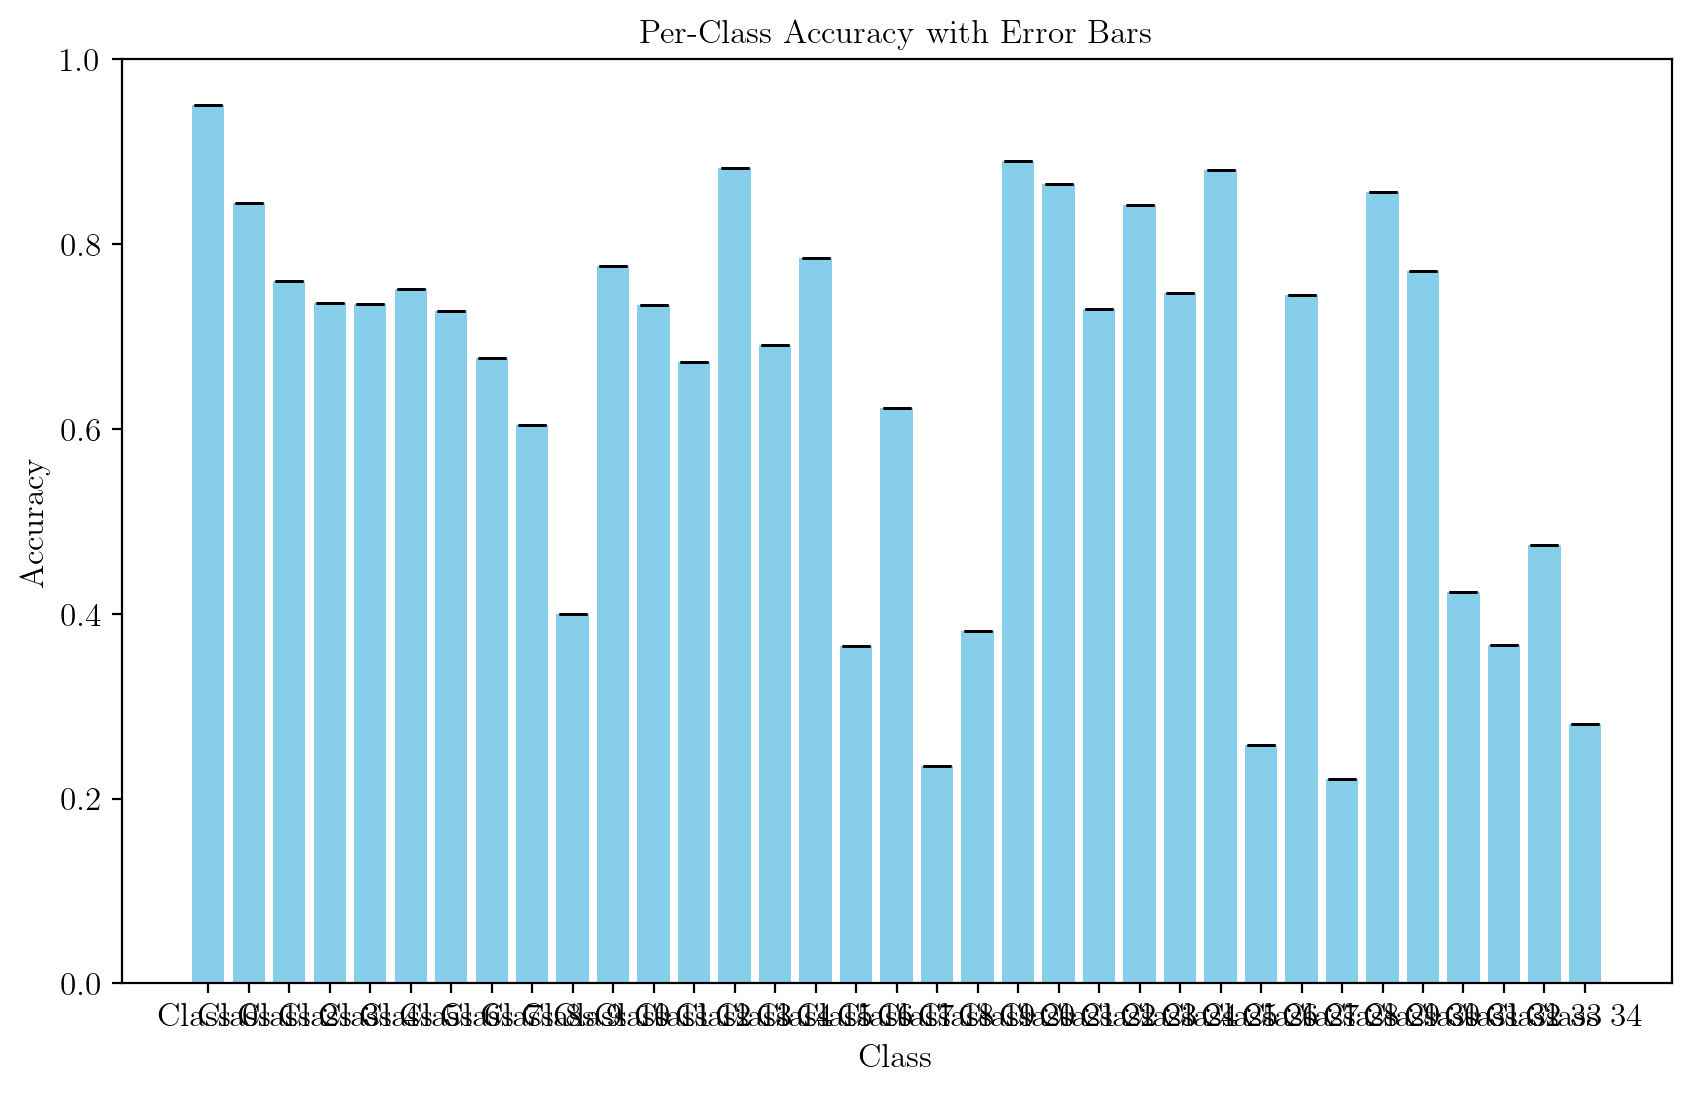

In [11]:


# Number of classes
num_classes = 35

# Initialize an array to store accuracies for each class across folds
class_accuracies_folds = np.zeros((len(kfold_models), num_classes))

# Calculate per-class accuracy for each fold
for fold_idx, model in enumerate(kfold_models):
    fold_accuracies = []
    for cls in tqdm(range(num_classes)):
        # Mask for the current class
        class_mask = (y_test == cls)
        # Calculate accuracy for the current fold and class
        class_accuracy = np.sum(model.predict(X_test).flatten()[class_mask] == y_test[class_mask]) / np.sum(class_mask)
        fold_accuracies.append(class_accuracy)
    class_accuracies_folds[fold_idx] = fold_accuracies

# Compute mean and standard deviation of accuracies across folds
class_accuracies_mean = class_accuracies_folds.mean(axis=0)
class_accuracies_std = class_accuracies_folds.std(axis=0)

# Bar plot with error bars
plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), class_accuracies_mean, yerr=class_accuracies_std, color='skyblue', capsize=5)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy with Error Bars')
plt.xticks(range(num_classes), [f'Class {i}' for i in range(num_classes)])
plt.ylim(0, 1)  # Accuracy goes from 0 to 1
plt.show()


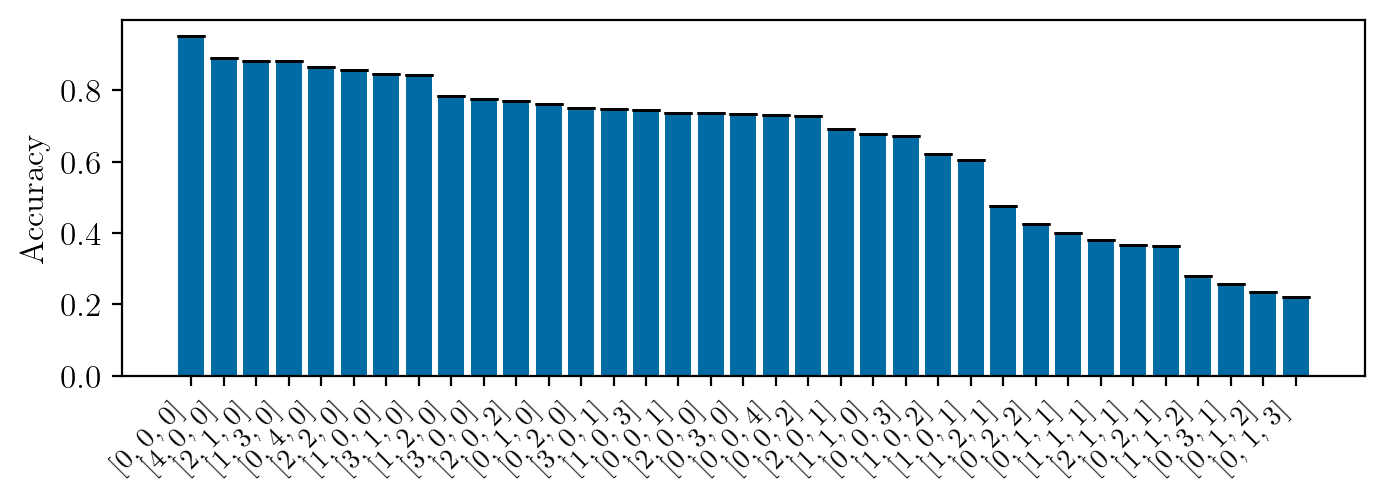

In [17]:
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}


custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Sort data by mean accuracies in descending order
sorted_indices = np.argsort(class_accuracies_mean)[::-1]
sorted_means = class_accuracies_mean[sorted_indices]
sorted_stds = class_accuracies_std[sorted_indices]
sorted_labels = [str(class_to_poles[i]) for i in sorted_indices]

# Plotting
fig, ax = plt.subplots(figsize=(3.54331*2, 3.54331*0.75))
ax.bar(range(num_classes), sorted_means, yerr=sorted_stds, capsize=5)
ax.set_ylabel('Accuracy')

ax.set_xticks(np.arange(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=10)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

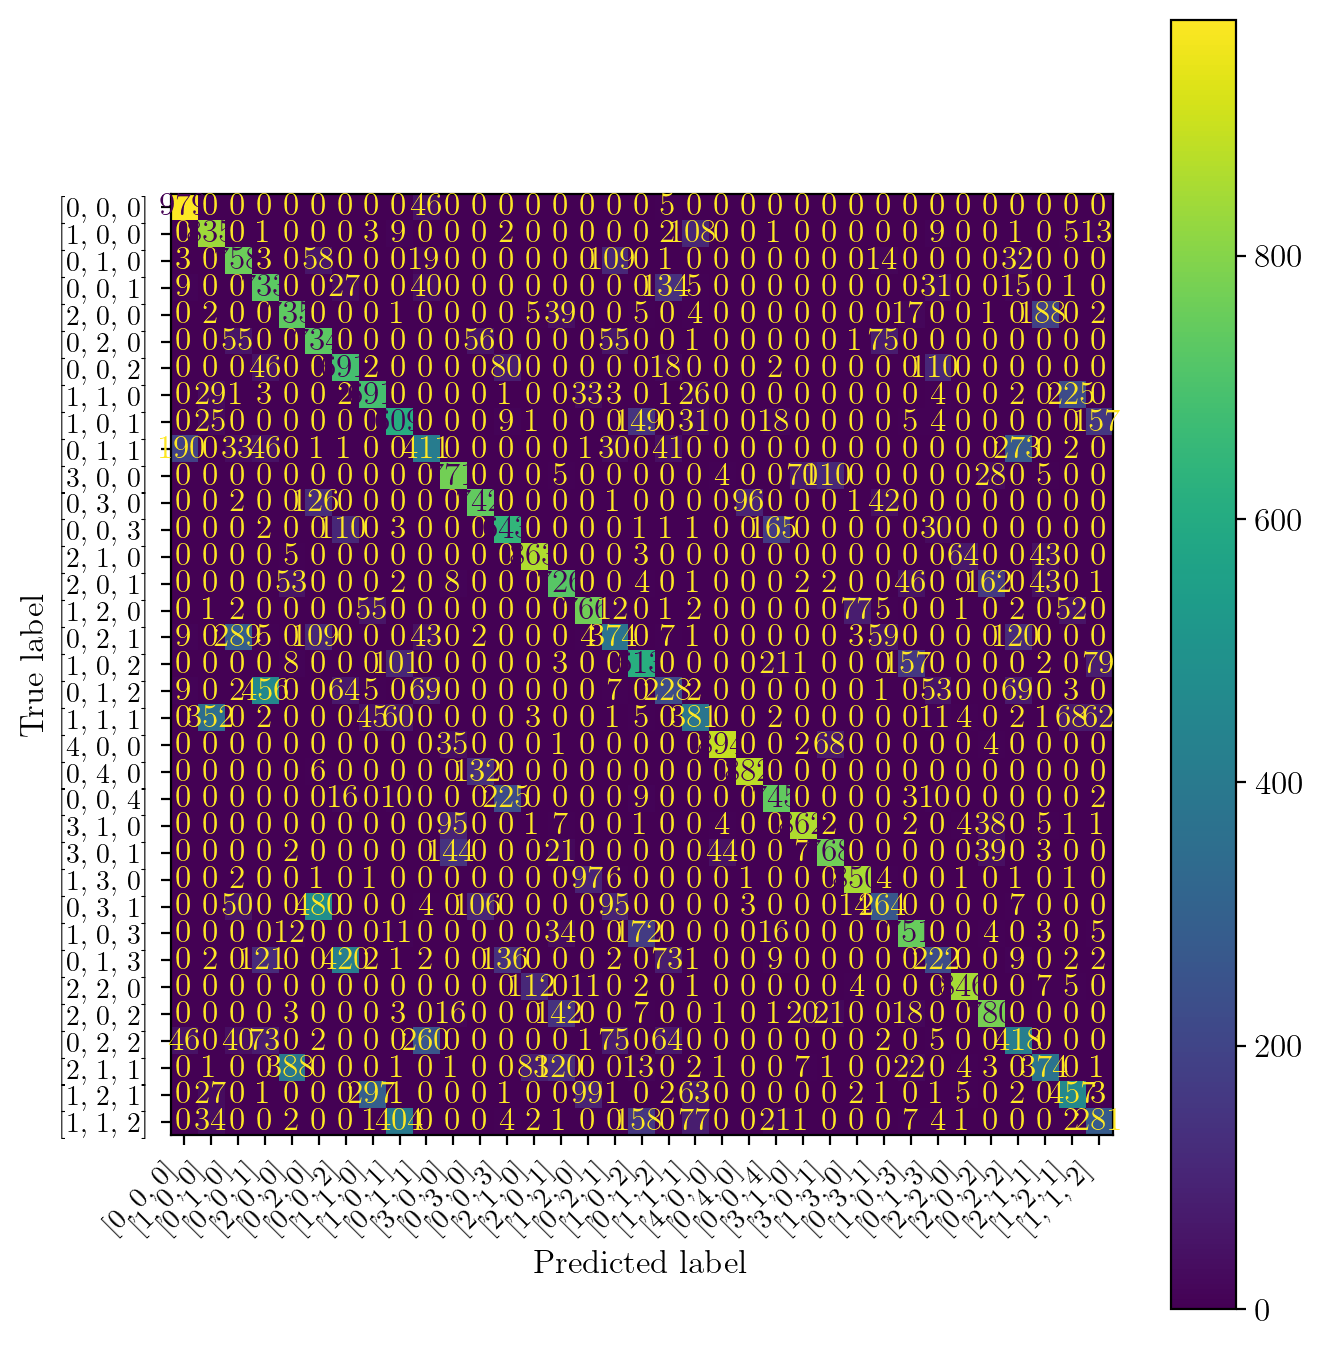

In [12]:
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}

# Custom labels for the axes
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Aggregate predictions over the folds
mean_predictions = np.zeros((len(X_test), len(class_to_poles)))
for model in kfold_models:
    fold_probs = model.predict_proba(X_test)  # Get probabilities for all classes
    mean_predictions += fold_probs
mean_predictions /= len(kfold_models)  # Average predictions across folds

# Get the final predicted class based on mean probabilities
final_predictions = np.argmax(mean_predictions, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, final_predictions, labels=np.arange(len(class_to_poles)))

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(7, 7))  # Adjust figure size if needed
disp.plot(ax=ax)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()


/home/felix/vscodeProjects/pole-learning/.venv_pole/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/felix/vscodeProjects/pole-learning/.venv_pole/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


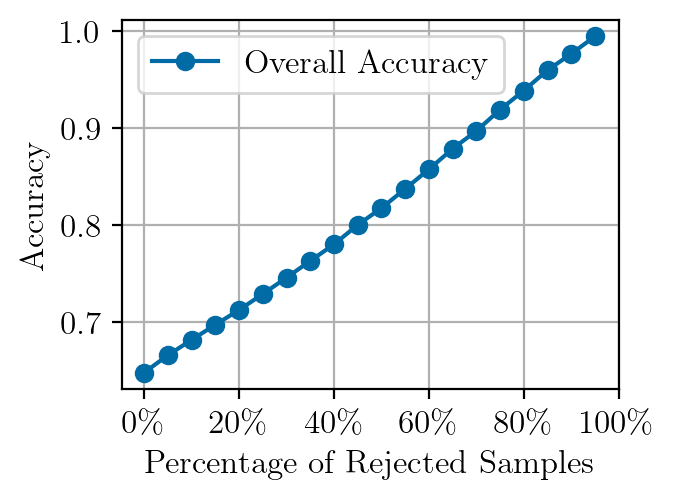

In [18]:
# Load the model
model = CatBoostClassifier()
model.load_model('saved_models/model_fold_clf_35_0')

# Get predicted probabilities
outputs = model.predict_proba(X_test)

# Calculate uncertainty as the difference from 0.5 (smaller values = more uncertain)
uncertainty = np.max(outputs, axis=1)  # Use max class probability to define certainty
sorted_indices = np.argsort(uncertainty)  # Sort by certainty (ascending)

# Define percentages to remove and track accuracies
percentages_removed = np.arange(0, 101, 5)  # Remove in 5% increments
accuracies = []

# Compute accuracy after removing uncertain samples
for perc in percentages_removed:
    num_to_remove = int((perc / 100) * len(outputs))
    remaining_indices = sorted_indices[num_to_remove:]  # Keep the most certain samples

    # Compute accuracy for the remaining samples
    y_pred = np.argmax(outputs[remaining_indices], axis=1)
    acc = accuracy_score(y_test[remaining_indices], y_pred)
    accuracies.append(acc)

# Plot using the requested style
fig, axs = plt.subplots(figsize=(3.54331, 3.54331 * 0.75))
axs.plot(percentages_removed, accuracies, "-o", label="Overall Accuracy")
axs.set_xlabel("Percentage of Rejected Samples")
axs.set_ylabel("Accuracy")
axs.legend()
axs.set_xticks([0, 20, 40, 60, 80, 100])
axs.set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
axs.grid(True)
fig.tight_layout()
plt.show()
